In [1]:
pip install pandas

In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import json
import os
import re

In [4]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Pre-processing

Cleaning snp matrix

In [8]:
snp_df = pd.read_csv("maf_prop_snp_matrix.csv")

# Separate id for cleaning
id_col = snp_df['id']
data = snp_df.drop(columns=['id'])

# Drop cols where all 0 
non_zero_cols = (data.iloc[1:] != 0).any(axis=0)
zero_cols = non_zero_cols[~non_zero_cols].index.tolist()
print(f"⚠️ Columns with all zeros: {len(zero_cols)}")
data = data.loc[:, non_zero_cols]

# Drop cols with null or empty string
has_null = data.isnull().any()
has_empty_str = (data == '').any()
missing_cols = has_null | has_empty_str
print(f"⚠️ Columns with null or empty string values: {missing_cols.sum()}")
no_missing_cols = ~missing_cols
data = data.loc[:, no_missing_cols]

⚠️ Columns with all zeros: 0
⚠️ Columns with null or empty string values: 0


In [9]:
# Check for null (NaN) values
null_counts = data.isna().sum()
total_nulls = null_counts.sum()

# Check for empty strings
empty_counts = (data == '').sum().sum()

# Check for strings with only whitespace
blank_counts = data.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum().sum()

print(f"🔍 Total null (NaN) values: {total_nulls}")
print(f"🔍 Total empty string values: {empty_counts}")
print(f"🔍 Total blank string values (only spaces/tabs): {blank_counts}")

# If you want to see which columns have issues
cols_with_null = data.isna().any()
cols_with_empty = (data == '').any()
cols_with_blank = data.applymap(lambda x: isinstance(x, str) and x.strip() == '').any()

print("⚠️ Columns with null values:", cols_with_null[cols_with_null].index.tolist())
print("⚠️ Columns with empty strings:", cols_with_empty[cols_with_empty].index.tolist())
print("⚠️ Columns with blank strings:", cols_with_blank[cols_with_blank].index.tolist())


🔍 Total null (NaN) values: 0
🔍 Total empty string values: 0
🔍 Total blank string values (only spaces/tabs): 0
⚠️ Columns with null values: []
⚠️ Columns with empty strings: []
⚠️ Columns with blank strings: []


C:\Users\hialo\AppData\Local\Temp\ipykernel_13432\1198684043.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  blank_counts = data.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum().sum()
C:\Users\hialo\AppData\Local\Temp\ipykernel_13432\1198684043.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cols_with_blank = data.applymap(lambda x: isinstance(x, str) and x.strip() == '').any()


In [10]:
final_df = pd.concat([id_col, data], axis=1)

final_df.to_csv("input_snps.csv", index=False)
print(f"✅ input_snps.csv created.\nShape: {final_df.shape}")

✅ input_snps.csv created.
Shape: (400, 102)


Combining input_snp with country and drug resistance pDST results for INH, RIF, PZA, and STM

In [12]:
snp_df = pd.read_csv("input_snps.csv")

# Remove .vcf
snp_df["id"] = snp_df["id"].str.replace(".vcf", "", regex=False)

xl = pd.ExcelFile("master_data.xlsx")
meta_df = xl.parse("All", header=1)[["isolate name", "ena_run", "country"]]

target_drugs = ["ISONIAZID", "RIFAMPICIN", "ETHAMBUTOL", "STREPTOMYCIN", "PYRAZINAMIDE", "LEVOFLOXACIN"]

for drug in target_drugs:
    if drug in xl.sheet_names:
        drug_df = xl.parse(drug)
        colname = f"{drug.lower()}_resistance"
        drug_df = drug_df.rename(columns={"resistance phenotype (pDST)": colname})
        drug_df[colname] = drug_df[colname].map({"R": 1, "S": 0})
        meta_df = meta_df.merge(drug_df[["isolate name", colname]], on="isolate name", how="left")
    else:
        print(f"⚠️ Sheet not found: {drug}")

missing_ids = set(snp_df["id"]) - set(meta_df["ena_run"])
for mid in missing_ids:
    print(f"⛔ Not found in master data excel: {mid}")

final_df = snp_df.merge(meta_df, left_on="id", right_on="ena_run", how="inner")
final_df = final_df.drop(columns=["ena_run", "isolate name"])

final_df.to_csv("0_input.csv", index=False)
print(f"✅ 0_input.csv created.\nShape: {final_df.shape}")

⛔ Not found in master data excel: ERR550776
⛔ Not found in master data excel: ERR2199933
⛔ Not found in master data excel: ERR046771
⛔ Not found in master data excel: ERR046937
⛔ Not found in master data excel: ERR046840
⛔ Not found in master data excel: ERR3794505
⛔ Not found in master data excel: ERR2199934
⛔ Not found in master data excel: ERR4872232
⛔ Not found in master data excel: ERR3794356
⛔ Not found in master data excel: ERR3794427
⛔ Not found in master data excel: ERR046847
⛔ Not found in master data excel: ERR2200091
⛔ Not found in master data excel: ERR3794472
⛔ Not found in master data excel: ERR038257
⛔ Not found in master data excel: ERR2200119
⛔ Not found in master data excel: ERR3794550
⛔ Not found in master data excel: ERR2200096
⛔ Not found in master data excel: ERR046965
⛔ Not found in master data excel: ERR2199999
⛔ Not found in master data excel: ERR3794420
✅ 0_input.csv created.
Shape: (380, 109)


In [13]:
print("\n")
print(final_df.head())



          id  Chromosome_6112_G_C  Chromosome_7362_G_C  Chromosome_7582_A_G  \
0  ERR067635                    0                    1                    1   
1  ERR067660                    0                    1                    0   
2  ERR067667                    0                    1                    0   
3  ERR067717                    0                    1                    0   
4  ERR067742                    0                    1                    0   

   Chromosome_7585_G_C  Chromosome_8452_C_T  Chromosome_9143_T_C  \
0                    1                    0                    0   
1                    1                    0                    0   
2                    1                    0                    0   
3                    1                    0                    0   
4                    1                    0                    0   

   Chromosome_9304_G_A  Chromosome_13298_G_C  Chromosome_13460_A_G  ...  \
0                    1                 

## Distributions

In [15]:
def extract_lineage(id_):
    json_path = os.path.join("results", f"{id_}.results.json")
    if not os.path.exists(json_path):
        print(f"⛔ Lineage file not found: {json_path}")
        return None
    
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
            if "lineage" in data and isinstance(data["lineage"], list) and data["lineage"]:
                lineage_str = data["lineage"][0]["lineage"]
                # Extract the number using regex
                match = re.search(r'\d+', lineage_str)
                if match:
                    return int(match.group())  # Return as int (optional)
                else:
                    print(f"⚠️ Could not extract number from lineage string: {lineage_str}")
            else:
                print(f"⚠️ No lineage data in: {json_path}")
    except Exception as e:
        print(f"⚠️ Error reading {json_path}: {e}")
    return None

final_df["lineage"] = final_df["id"].apply(extract_lineage)

final_df.to_csv("0_input_with_lineage.csv", index=False)
print(f"✅ 0_input_with_lineage.csv created.\nShape: {final_df.shape}")

⚠️ No lineage data in: results\ERR2516384.results.json
✅ 0_input_with_lineage.csv created.
Shape: (380, 110)


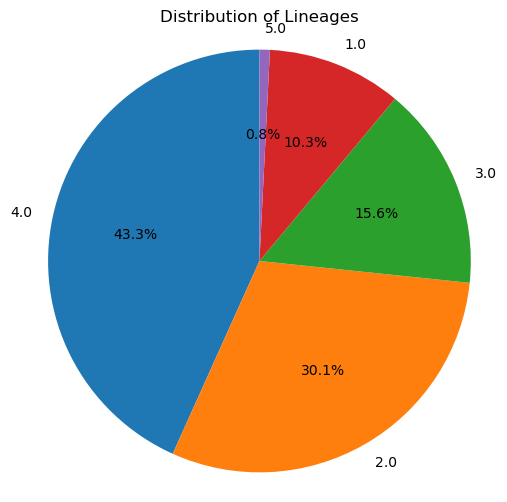


Lineage Distribution Table:
 Lineage  Count  Percentage
     4.0    164        43.3
     2.0    114        30.1
     3.0     59        15.6
     1.0     39        10.3
     5.0      3         0.8


In [16]:
lineage_counts = final_df['lineage'].dropna().value_counts()

plt.figure(figsize=(6, 6))
plt.pie(lineage_counts, labels=lineage_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Lineages')
plt.axis('equal')  
plt.show()

lineage_table = pd.DataFrame({
    'Lineage': lineage_counts.index,
    'Count': lineage_counts.values,
    'Percentage': (lineage_counts.values / lineage_counts.sum() * 100).round(1)
})
print("\nLineage Distribution Table:")
print(lineage_table.to_string(index=False))


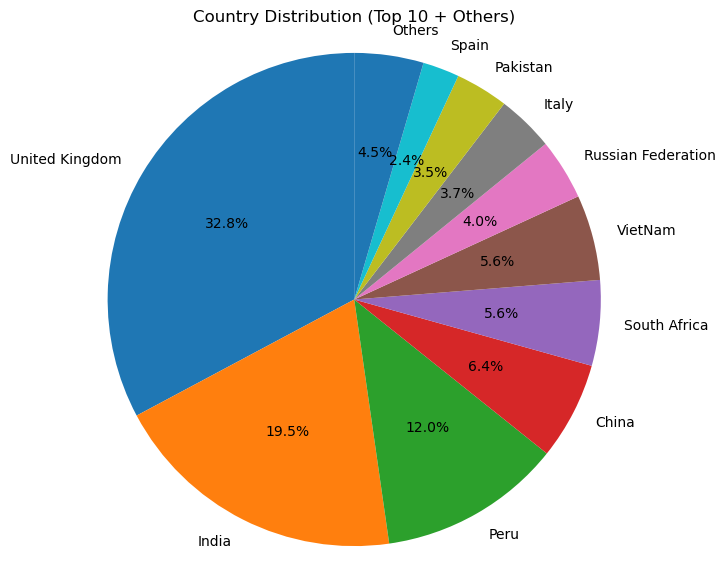


Country Distribution Table:
           Country  Count  Percentage
    United Kingdom    123        32.8
             India     73        19.5
              Peru     45        12.0
             China     24         6.4
      South Africa     21         5.6
           VietNam     21         5.6
Russian Federation     15         4.0
             Italy     14         3.7
          Pakistan     13         3.5
             Spain      9         2.4
            Others     17         4.5


In [19]:
country_counts = final_df['country'].dropna().value_counts()

top_n = 10
top_countries = country_counts[:top_n]
others = country_counts[top_n:].sum()
if others > 0:
    top_countries["Others"] = others

plt.figure(figsize=(7, 7))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=90)
plt.title('Country Distribution (Top 10 + Others)')
plt.axis('equal')
plt.show()

country_table = pd.DataFrame({
    'Country': top_countries.index,
    'Count': top_countries.values,
    'Percentage': (top_countries.values / top_countries.sum() * 100).round(1)
})
print("\nCountry Distribution Table:")
print(country_table.to_string(index=False))


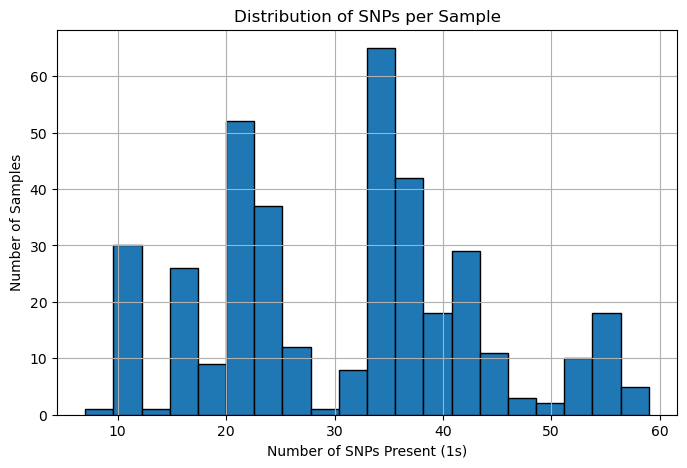


SNP Distribution Table:
 Number of SNPs Present (1s)  Number of Samples
                         7.0                  1
                        10.0                  2
                        11.0                  6
                        12.0                 22
                        14.0                  1
                        15.0                  6
                        16.0                  4
                        17.0                 16
                        18.0                  7
                        19.0                  2
                        20.0                  6
                        21.0                 26
                        22.0                 20
                        23.0                  5
                        24.0                  6
                        25.0                 26
                        26.0                  9
                        27.0                  3
                        29.0                  1
               

In [20]:
# idk is thiss relevant ?
snp_df = final_df.drop(columns=['id'], errors='ignore')

snp_df = snp_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# 1s per row
snp_counts_per_sample = snp_df.sum(axis=1)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(snp_counts_per_sample, bins=20, edgecolor='black')
plt.title("Distribution of SNPs per Sample")
plt.xlabel("Number of SNPs Present (1s)")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# Create and print summary table
snp_distribution_table = snp_counts_per_sample.value_counts().sort_index().reset_index()
snp_distribution_table.columns = ['Number of SNPs Present (1s)', 'Number of Samples']
print("\nSNP Distribution Table:")
print(snp_distribution_table.to_string(index=False))

In [21]:
# Check for null (NaN) values
null_counts = snp_df.isna().sum()
total_nulls = null_counts.sum()

# Check for empty strings
empty_counts = (snp_df == '').sum().sum()

# Check for strings with only whitespace
blank_counts = snp_df.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum().sum()

print(f"🔍 Total null (NaN) values: {total_nulls}")
print(f"🔍 Total empty string values: {empty_counts}")
print(f"🔍 Total blank string values (only spaces/tabs): {blank_counts}")

# If you want to see which columns have issues
cols_with_null = snp_df.isna().any()
cols_with_empty = (snp_df == '').any()
cols_with_blank = snp_df.applymap(lambda x: isinstance(x, str) and x.strip() == '').any()

print("⚠️ Columns with null values:", cols_with_null[cols_with_null].index.tolist())
print("⚠️ Columns with empty strings:", cols_with_empty[cols_with_empty].index.tolist())
print("⚠️ Columns with blank strings:", cols_with_blank[cols_with_blank].index.tolist())


🔍 Total null (NaN) values: 0
🔍 Total empty string values: 0
🔍 Total blank string values (only spaces/tabs): 0
⚠️ Columns with null values: []
⚠️ Columns with empty strings: []
⚠️ Columns with blank strings: []


C:\Users\hialo\AppData\Local\Temp\ipykernel_26748\1658531333.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  blank_counts = snp_df.applymap(lambda x: isinstance(x, str) and x.strip() == '').sum().sum()
C:\Users\hialo\AppData\Local\Temp\ipykernel_26748\1658531333.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cols_with_blank = snp_df.applymap(lambda x: isinstance(x, str) and x.strip() == '').any()


## Random Forest

Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

### Isoniazid resistance prediction

In [21]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

INH_na = input_df['isoniazid_resistance'].isna().sum()
print("Missing values before drop:", INH_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['isoniazid_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 55


In [22]:
columns_to_drop = ['rifampicin_resistance', 'ethambutol_resistance', 'streptomycin_resistance', 'pyrazinamide_resistance', 'levofloxacin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['isoniazid_resistance'] = input_df['isoniazid_resistance'].astype(int)

In [23]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 119)


In [24]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

lineage    1
dtype: int64


In [25]:
input_df = input_df.dropna(subset=['lineage'])
print("Shape after drop:", input_df.shape)

Shape after drop: (324, 119)


In [26]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


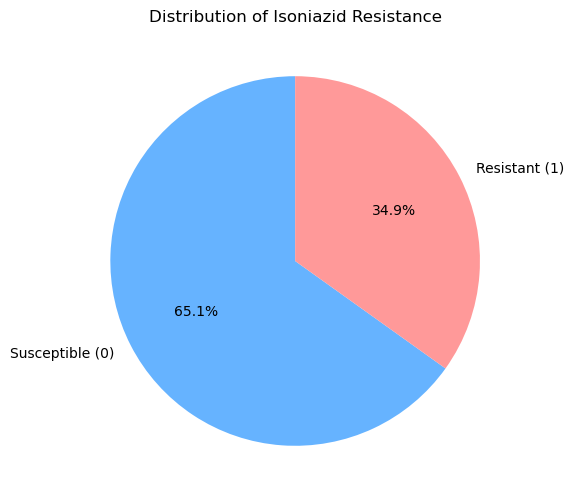

In [27]:
counts = input_df['isoniazid_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Isoniazid Resistance")
plt.show()

#### Training

In [29]:
X_with_lineage = input_df.drop(columns=['isoniazid_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['isoniazid_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (324, 118)
Shape of X_without_lineage (features): (324, 117)
Shape of y (target): (324,)


In [30]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (324, 118)
Shape of X_without_lineage: (324, 117)
Shape of y (target): (324,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (259, 117)
Testing feature shape: (65, 117)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (259, 118)
Testing feature shape: (65, 118)


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# === WITH lineage (No SMOTE) ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results = []
cv_results.append({
    "Drug": "INH",
    "Model": "With Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === WITHOUT lineage (No SMOTE) ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "INH",
    "Model": "Without Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

# === Test WITH lineage (SMOTE on train) ===
pipeline_wi_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wi_test.fit(X_train_wi, y_train)
y_pred_wi_smote = pipeline_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "INH",
    "Model": "With Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_smote),
    "Precision": precision_score(y_test, y_pred_wi_smote),
    "Recall": recall_score(y_test, y_pred_wi_smote),
    "F1 Score": f1_score(y_test, y_pred_wi_smote),
})

# === Test WITHOUT lineage (SMOTE on train) ===
pipeline_wo_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wo_test.fit(X_train_wo, y_train)
y_pred_wo_smote = pipeline_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "INH",
    "Model": "Without Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_smote),
    "Precision": precision_score(y_test, y_pred_wo_smote),
    "Recall": recall_score(y_test, y_pred_wo_smote),
    "F1 Score": f1_score(y_test, y_pred_wo_smote),
})


#### Performance metrics

In [34]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,INH,"With Lineage (Test, No SMOTE)",0.88,0.89,0.74,0.81
1,INH,"Without Lineage (Test, No SMOTE)",0.88,0.89,0.74,0.81
2,INH,"With Lineage (Test, SMOTE)",0.86,0.85,0.74,0.79
3,INH,"Without Lineage (Test, SMOTE)",0.78,0.68,0.74,0.71


Confusion Matrix - With Lineage (Test, No SMOTE)


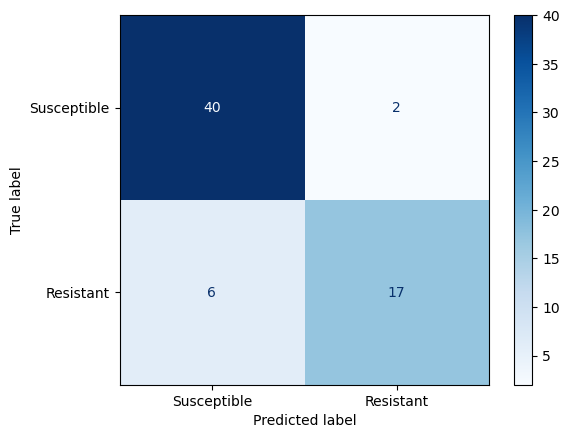

Confusion Matrix - Without Lineage (Test, No SMOTE)


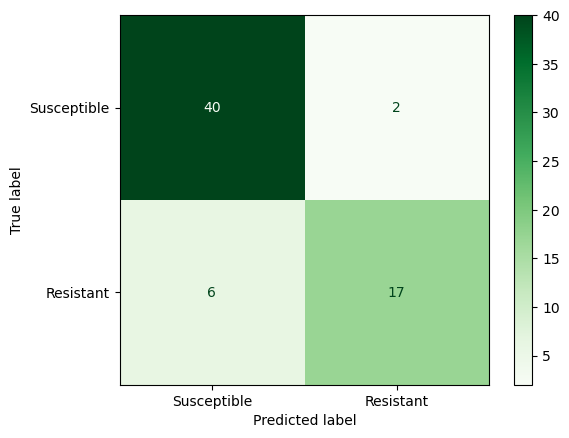

Confusion Matrix - With Lineage (Test, SMOTE)


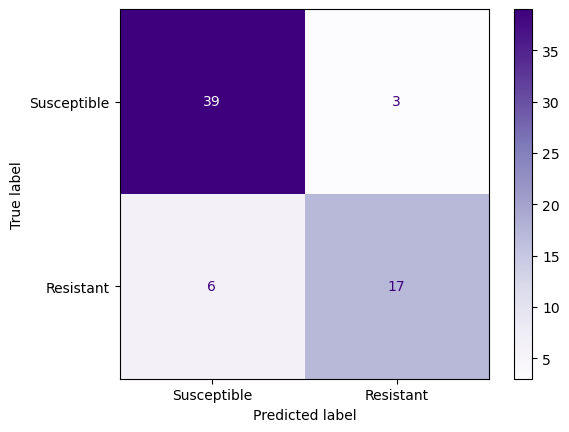

Confusion Matrix - Without Lineage (Test, SMOTE)


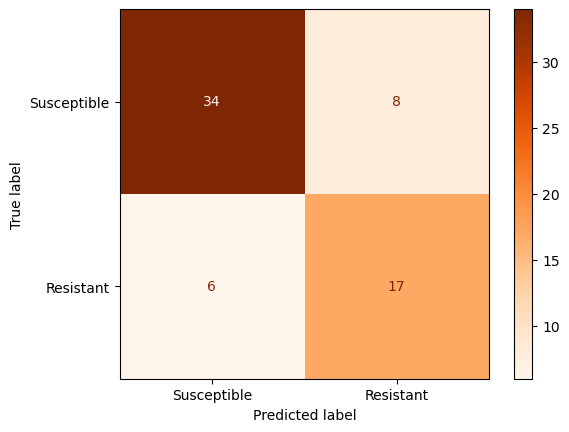

In [35]:
# === Confusion Matrix: With Lineage (Test, No SMOTE) ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, No SMOTE)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, No SMOTE) ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, No SMOTE)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

# === Confusion Matrix: With Lineage (Test, SMOTE) ===
cm_wi_smote = confusion_matrix(y_test, y_pred_wi_smote)
disp_wi_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wi_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, SMOTE)")
disp_wi_smote.plot(cmap="Purples")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, SMOTE) ===
cm_wo_smote = confusion_matrix(y_test, y_pred_wo_smote)
disp_wo_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wo_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, SMOTE)")
disp_wo_smote.plot(cmap="Oranges")
plt.grid(False)
plt.show()


#### Tree visualization

=== Decision Trees from Random Forest (With Lineage) ===


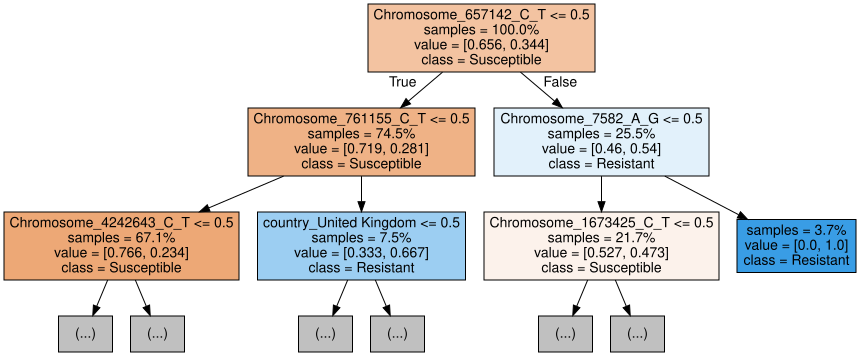

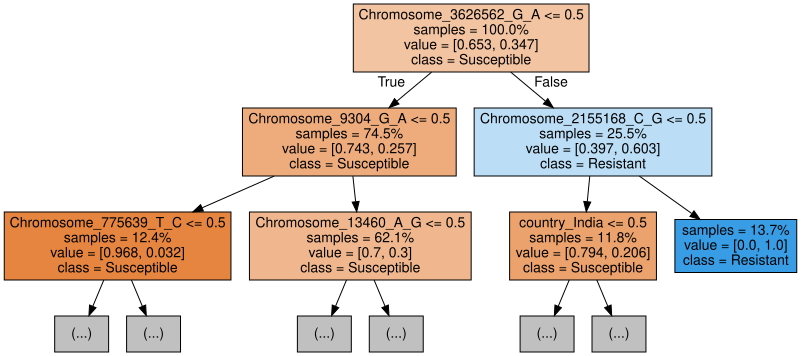

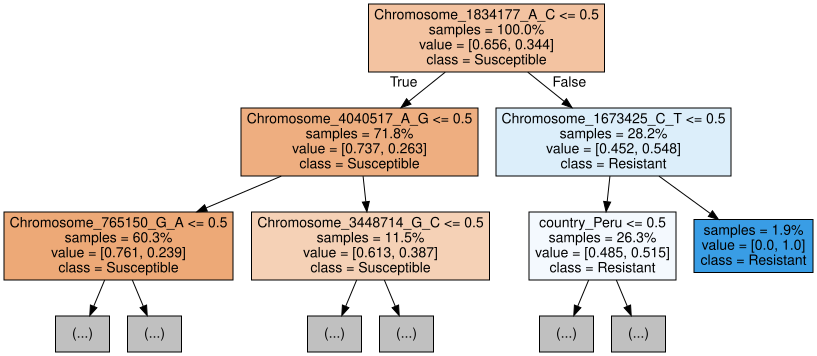


=== Decision Trees from Random Forest (Without Lineage) ===


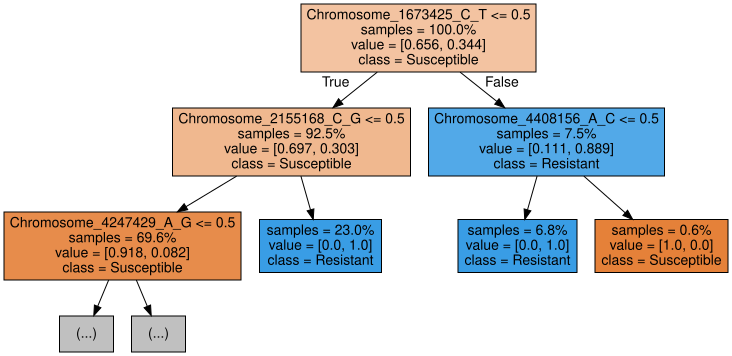

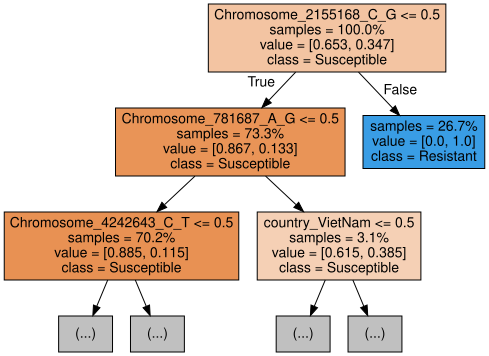

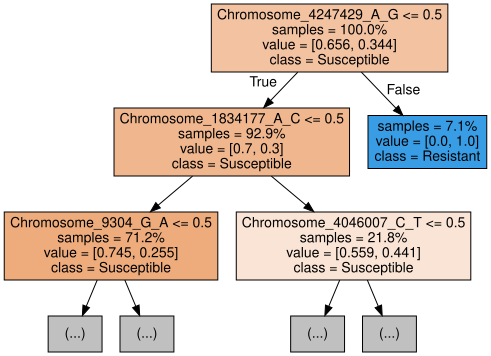

In [83]:
# === Visualize 3 Trees from Random Forest (With Lineage)
print("=== Decision Trees from Random Forest (With Lineage) ===")
for i in range(3):
    tree = rf_wi_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wi.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_with_lineage_{i}", format="png", cleanup=True)

# === Visualize 3 Trees from Random Forest (Without Lineage)
print("\n=== Decision Trees from Random Forest (Without Lineage) ===")
for i in range(3):
    tree = rf_wo_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wo.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_without_lineage_{i}", format="png", cleanup=True)


#### Feature importance

In [37]:
# === Feature Importances: With Lineage ===
importances_wi = rf_wi_test.feature_importances_
features_wi = X_train_wi.columns

fi_df_wi = pd.DataFrame({
    'Feature': features_wi,
    'Importance': importances_wi
}).sort_values(by='Importance', ascending=False)

print("=== Feature Importances: With Lineage ===")
print(fi_df_wi)

=== Feature Importances: With Lineage ===
                   Feature  Importance
53  Chromosome_2155168_C_G    0.340302
21   Chromosome_761155_C_T    0.136851
45  Chromosome_1673425_C_T    0.112712
35   Chromosome_781687_A_G    0.049183
87  Chromosome_4247429_A_G    0.038432
..                     ...         ...
69  Chromosome_3624486_T_C    0.000120
30   Chromosome_775639_T_C    0.000041
34   Chromosome_781395_T_C    0.000004
1      Chromosome_7362_G_C    0.000000
43  Chromosome_1471659_C_T    0.000000

[118 rows x 2 columns]


C:\Users\hialo\AppData\Local\Temp\ipykernel_28072\2906224505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df_wi.head(10), palette='Blues_r')


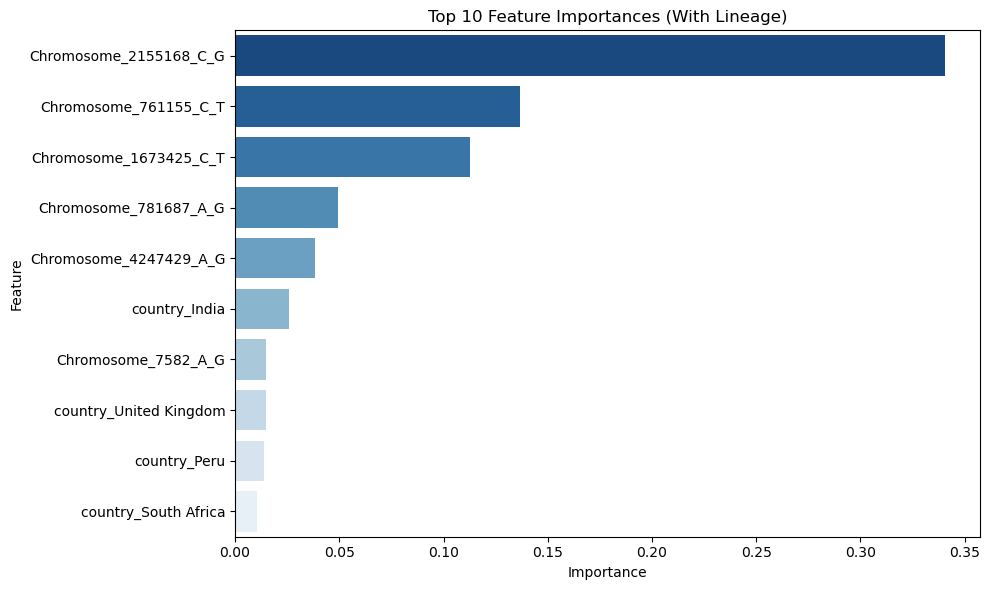

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_wi.head(10), palette='Blues_r')
plt.title('Top 10 Feature Importances (With Lineage)')
plt.tight_layout()
plt.show()

In [39]:
threshold = 1e-3
near_zero_wi = fi_df_wi[fi_df_wi['Importance'] < threshold]['Feature'].tolist()

print(f"{len(near_zero_wi)} features have importance < {threshold} (With Lineage):\n")
for i, feature in enumerate(near_zero_wi, 1):
    print(f"{i}. {feature}")

42 features have importance < 0.001 (With Lineage):

1. Chromosome_1417554_G_C
2. country_Belgium
3. Chromosome_4044872_G_A
4. Chromosome_2518076_C_T
5. Chromosome_1254562_A_G
6. Chromosome_4242075_G_A
7. Chromosome_800357_C_A
8. Chromosome_2222308_T_C
9. Chromosome_4328492_G_A
10. country_Spain
11. Chromosome_4138622_G_A
12. Chromosome_763884_C_T
13. Chromosome_4269606_A_G
14. Chromosome_4249408_G_A
15. Chromosome_1417019_C_T
16. Chromosome_4247646_A_C
17. Chromosome_4407873_C_A
18. Chromosome_734116_T_C
19. Chromosome_1853974_C_T
20. Chromosome_13460_A_G
21. Chromosome_2518132_C_T
22. Chromosome_575679_A_G
23. Chromosome_2782498_G_A
24. Chromosome_1417793_G_A
25. Chromosome_4040517_A_G
26. Chromosome_4338603_G_A
27. Chromosome_8452_C_T
28. Chromosome_2223293_T_C
29. Chromosome_2726051_G_A
30. Chromosome_657578_A_G
31. Chromosome_4241042_A_G
32. country_Nepal
33. Chromosome_763886_C_A
34. Chromosome_2062922_T_C
35. Chromosome_6112_G_C
36. Chromosome_4269387_T_G
37. Chromosome_13298_G_

In [40]:
# === Feature Importances: Without Lineage ===
importances_wo = rf_wo_test.feature_importances_
features_wo = X_train_wo.columns

fi_df_wo = pd.DataFrame({
    'Feature': features_wo,
    'Importance': importances_wo
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importances: Without Lineage ===")
print(fi_df_wo)


=== Feature Importances: Without Lineage ===
                   Feature  Importance
53  Chromosome_2155168_C_G    0.325636
21   Chromosome_761155_C_T    0.151229
45  Chromosome_1673425_C_T    0.116082
35   Chromosome_781687_A_G    0.045812
87  Chromosome_4247429_A_G    0.041981
..                     ...         ...
81  Chromosome_4241042_A_G    0.000071
34   Chromosome_781395_T_C    0.000009
30   Chromosome_775639_T_C    0.000009
1      Chromosome_7362_G_C    0.000000
43  Chromosome_1471659_C_T    0.000000

[117 rows x 2 columns]


C:\Users\hialo\AppData\Local\Temp\ipykernel_28072\3033769339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df_wo.head(10), palette='Greens_r')


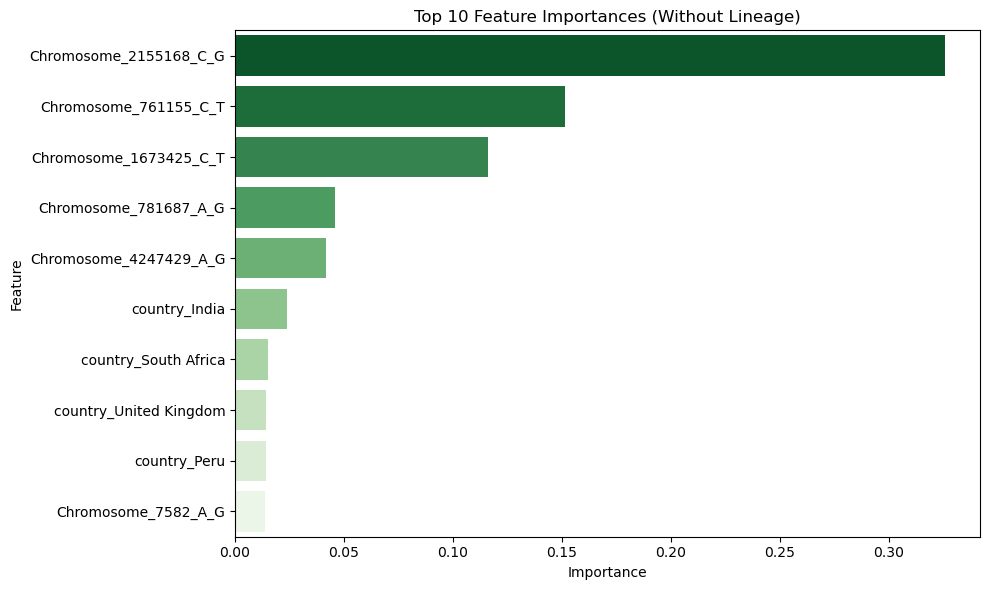

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_wo.head(10), palette='Greens_r')
plt.title('Top 10 Feature Importances (Without Lineage)')
plt.tight_layout()
plt.show()

In [42]:
threshold = 1e-3
near_zero_wo = fi_df_wo[fi_df_wo['Importance'] < threshold]['Feature'].tolist()

print(f"{len(near_zero_wo)} features have importance < {threshold} (Without Lineage):\n")
for i, feature in enumerate(near_zero_wo, 1):
    print(f"{i}. {feature}")

43 features have importance < 0.001 (Without Lineage):

1. Chromosome_800219_T_C
2. Chromosome_762434_T_G
3. country_Ethiopia
4. Chromosome_9143_T_C
5. Chromosome_4242075_G_A
6. Chromosome_4138377_A_G
7. Chromosome_4269387_T_G
8. Chromosome_763886_C_A
9. country_Spain
10. Chromosome_657142_C_T
11. Chromosome_13460_A_G
12. Chromosome_4328492_G_A
13. Chromosome_734116_T_C
14. Chromosome_2518132_C_T
15. Chromosome_575679_A_G
16. Chromosome_1417554_G_C
17. Chromosome_763884_C_T
18. Chromosome_4240671_C_T
19. Chromosome_4245969_C_T
20. Chromosome_4338603_G_A
21. Chromosome_800357_C_A
22. Chromosome_4247646_A_C
23. Chromosome_2223293_T_C
24. Chromosome_2222308_T_C
25. Chromosome_4138622_G_A
26. Chromosome_3624486_T_C
27. Chromosome_2062922_T_C
28. Chromosome_6112_G_C
29. Chromosome_4407873_C_A
30. Chromosome_1417019_C_T
31. Chromosome_1853974_C_T
32. Chromosome_4269606_A_G
33. Chromosome_4040517_A_G
34. country_Nepal
35. Chromosome_13298_G_C
36. Chromosome_657578_A_G
37. Chromosome_8452_C_T


#### Hyperparameter Tuning

Source: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

In [172]:
# === With lineage ===
X_train_tune = X_train_wi
y_train_tune = y_train

# === Hyperparameter Grid ===
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# === Grid Search with Cross-Validation ===
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train_tune, y_train_tune)

# === Results ===
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("Best Estimator:\n", grid_search.best_estimator_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
Best CV Accuracy: 0.9423076923076923
Best Estimator:
 RandomForestClassifier(n_estimators=1000, random_state=42)


In [175]:
# === With lineage ===
X_train_tune = X_train_wo
y_train_tune = y_train

# === Hyperparameter Grid ===
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# === Grid Search with Cross-Validation ===
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train_tune, y_train_tune)

# === Results ===
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("Best Estimator:\n", grid_search.best_estimator_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV Accuracy: 0.9423076923076923
Best Estimator:
 RandomForestClassifier(n_estimators=500, random_state=42)


#### Updated model with feature importance & hyperparemeter tuning

In [178]:
threshold = 1e-3

near_zero_wi = fi_df_wi[fi_df_wi['Importance'] < threshold]['Feature'].tolist()
near_zero_wo = fi_df_wo[fi_df_wo['Importance'] < threshold]['Feature'].tolist()

X_train_wi_reduced = X_train_wi.drop(columns=near_zero_wi)
X_test_wi_reduced = X_test_wi.drop(columns=near_zero_wi)

X_train_wo_reduced = X_train_wo.drop(columns=near_zero_wo)
X_test_wo_reduced = X_test_wo.drop(columns=near_zero_wo)

In [180]:
# With Lineage
best_params_wi = {
    'bootstrap': True,
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 1000
}

# Without Lineage
best_params_wo = {
    'bootstrap': True,
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 500
}

# Train With Lineage
rf_wi_best = RandomForestClassifier(**best_params_wi, random_state=42)
rf_wi_best.fit(X_train_wi_reduced, y_train)
y_pred_wi_best = rf_wi_best.predict(X_test_wi_reduced)

# Train Without Lineage
rf_wo_best = RandomForestClassifier(**best_params_wo, random_state=42)
rf_wo_best.fit(X_train_wo_reduced, y_train)
y_pred_wo_best = rf_wo_best.predict(X_test_wo_reduced)

In [181]:
results_refit = []

results_refit.append({
    "Drug": "INH",
    "Model": "With Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_best),
    "Precision": precision_score(y_test, y_pred_wi_best),
    "Recall": recall_score(y_test, y_pred_wi_best),
    "F1 Score": f1_score(y_test, y_pred_wi_best),
})

results_refit.append({
    "Drug": "INH",
    "Model": "Without Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_best),
    "Precision": precision_score(y_test, y_pred_wo_best),
    "Recall": recall_score(y_test, y_pred_wo_best),
    "F1 Score": f1_score(y_test, y_pred_wo_best),
})

results_refit_df = pd.DataFrame(results_refit)
results_refit_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_refit_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_refit_df


,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,INH,With Lineage (Test),0.89,0.94,0.74,0.83
1,INH,Without Lineage (Test),0.89,0.94,0.74,0.83


Confusion Matrix - With Lineage (Best Params + Feature Reduction)


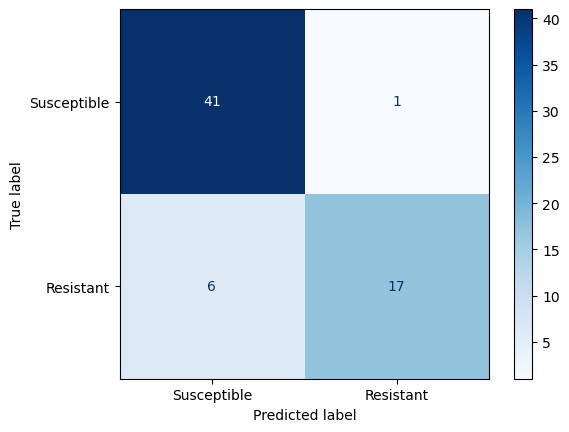

Confusion Matrix - Without Lineage (Best Params + Feature Reduction)


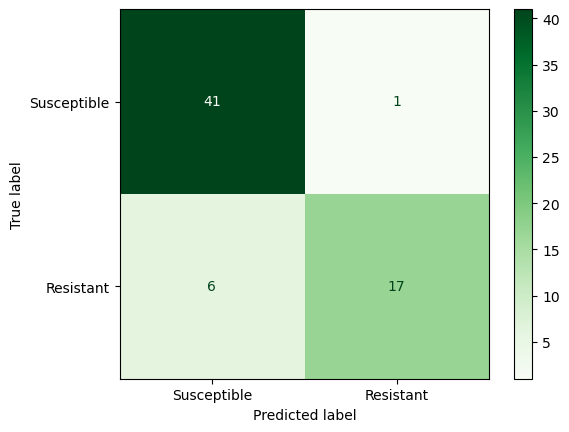

In [184]:
# With Lineage
cm_wi_best = confusion_matrix(y_test, y_pred_wi_best)
disp_wi_best = ConfusionMatrixDisplay(confusion_matrix=cm_wi_best, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Best Params + Feature Reduction)")
disp_wi_best.plot(cmap="Blues")
plt.grid(False)
plt.show()

# Without Lineage
cm_wo_best = confusion_matrix(y_test, y_pred_wo_best)
disp_wo_best = ConfusionMatrixDisplay(confusion_matrix=cm_wo_best, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Best Params + Feature Reduction)")
disp_wo_best.plot(cmap="Greens")
plt.grid(False)
plt.show()

### Rifampicin resistance prediction

In [55]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

RIF_na = input_df['rifampicin_resistance'].isna().sum()
print("Missing values before drop:", RIF_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['rifampicin_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 55


In [67]:
columns_to_drop = ['isoniazid_resistance', 'ethambutol_resistance', 'streptomycin_resistance', 'pyrazinamide_resistance', 'levofloxacin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['rifampicin_resistance'] = input_df['rifampicin_resistance'].astype(int)

In [69]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 118)


In [73]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

lineage    1
dtype: int64


In [75]:
input_df = input_df.dropna(subset=['lineage'])
print("Shape after drop:", input_df.shape)

Shape after drop: (324, 118)


In [77]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


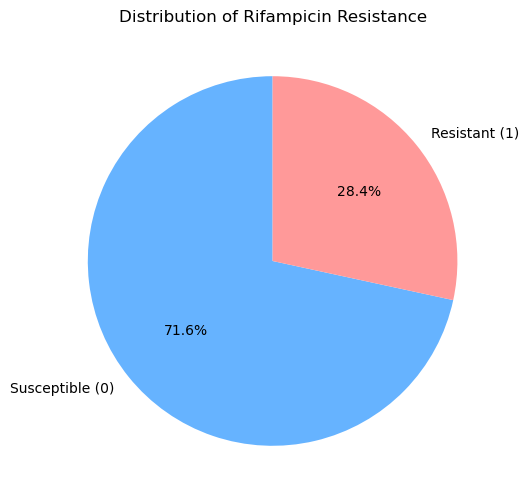

In [79]:
counts = input_df['rifampicin_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Rifampicin Resistance")
plt.show()

#### Training

In [81]:
X_with_lineage = input_df.drop(columns=['rifampicin_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['rifampicin_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (324, 117)
Shape of X_without_lineage (features): (324, 116)
Shape of y (target): (324,)


In [83]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [85]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (324, 117)
Shape of X_without_lineage: (324, 116)
Shape of y (target): (324,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (259, 116)
Testing feature shape: (65, 116)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (259, 117)
Testing feature shape: (65, 117)


In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# === WITH lineage (No SMOTE) ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results = []
cv_results.append({
    "Drug": "RIF",
    "Model": "With Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === WITHOUT lineage (No SMOTE) ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "RIF",
    "Model": "Without Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

# === Test WITH lineage (SMOTE on train) ===
pipeline_wi_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wi_test.fit(X_train_wi, y_train)
y_pred_wi_smote = pipeline_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "RIF",
    "Model": "With Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_smote),
    "Precision": precision_score(y_test, y_pred_wi_smote),
    "Recall": recall_score(y_test, y_pred_wi_smote),
    "F1 Score": f1_score(y_test, y_pred_wi_smote),
})

# === Test WITHOUT lineage (SMOTE on train) ===
pipeline_wo_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wo_test.fit(X_train_wo, y_train)
y_pred_wo_smote = pipeline_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "RIF",
    "Model": "Without Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_smote),
    "Precision": precision_score(y_test, y_pred_wo_smote),
    "Recall": recall_score(y_test, y_pred_wo_smote),
    "F1 Score": f1_score(y_test, y_pred_wo_smote),
})


#### Performance metrics

In [96]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,RIF,"With Lineage (Test, No SMOTE)",0.88,0.81,0.72,0.76
1,RIF,"Without Lineage (Test, No SMOTE)",0.88,0.81,0.72,0.76
2,RIF,"With Lineage (Test, SMOTE)",0.86,0.76,0.72,0.74
3,RIF,"Without Lineage (Test, SMOTE)",0.85,0.70,0.78,0.74


Confusion Matrix - With Lineage (Test, No SMOTE)


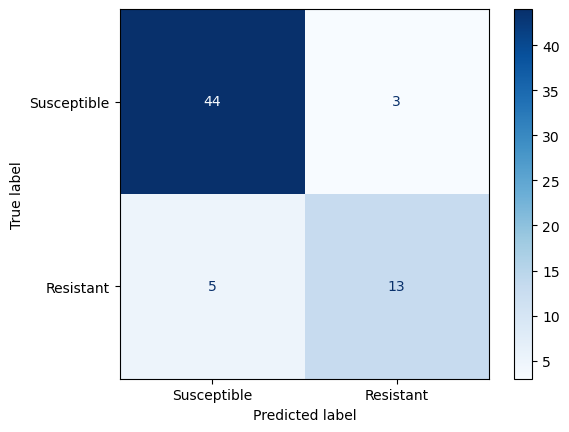

Confusion Matrix - Without Lineage (Test, No SMOTE)


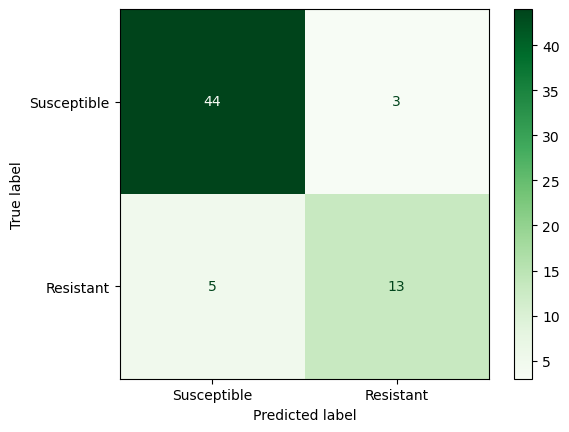

Confusion Matrix - With Lineage (Test, SMOTE)


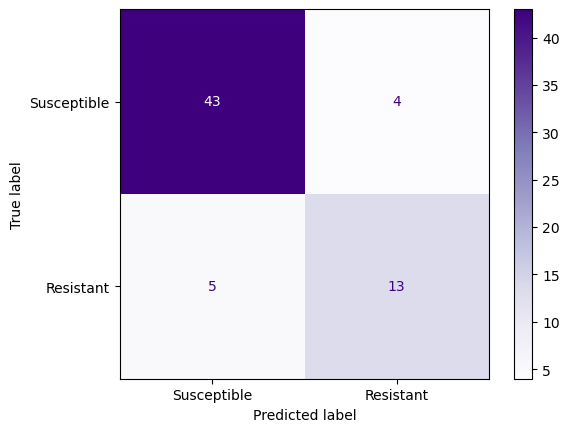

Confusion Matrix - Without Lineage (Test, SMOTE)


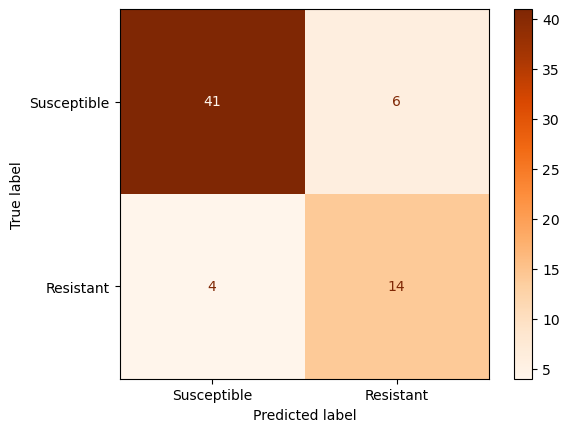

In [98]:
# === Confusion Matrix: With Lineage (Test, No SMOTE) ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, No SMOTE)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, No SMOTE) ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, No SMOTE)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

# === Confusion Matrix: With Lineage (Test, SMOTE) ===
cm_wi_smote = confusion_matrix(y_test, y_pred_wi_smote)
disp_wi_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wi_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, SMOTE)")
disp_wi_smote.plot(cmap="Purples")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, SMOTE) ===
cm_wo_smote = confusion_matrix(y_test, y_pred_wo_smote)
disp_wo_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wo_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, SMOTE)")
disp_wo_smote.plot(cmap="Oranges")
plt.grid(False)
plt.show()


=== Decision Trees from Random Forest (With Lineage) ===


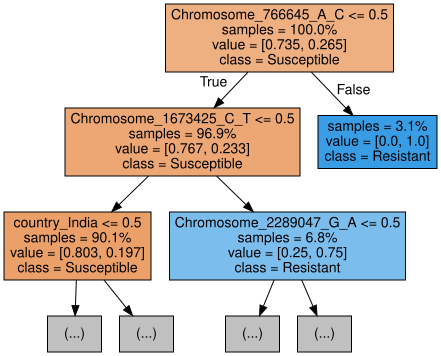

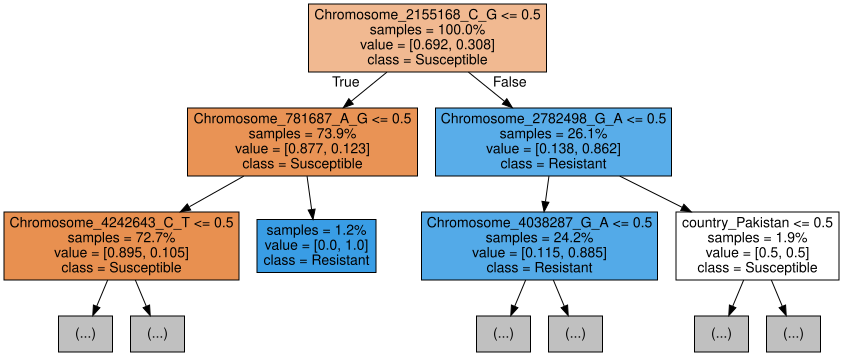

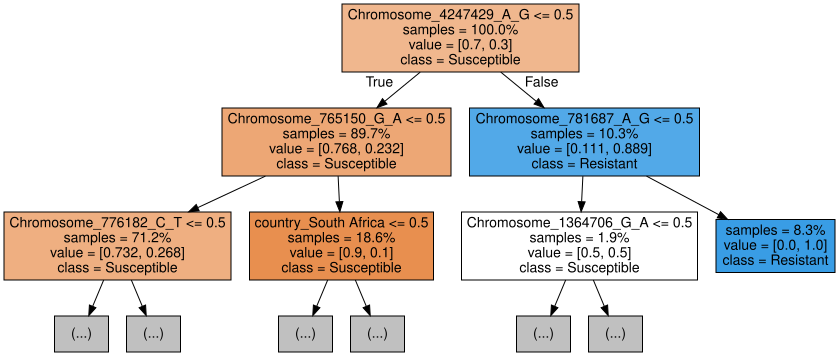


=== Decision Trees from Random Forest (Without Lineage) ===


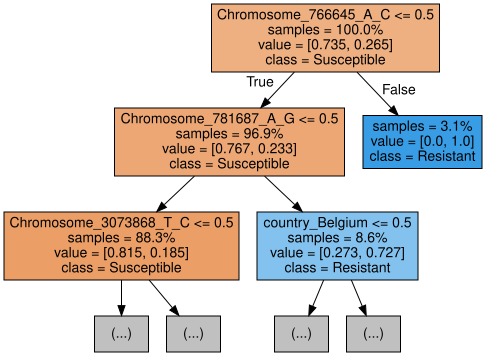

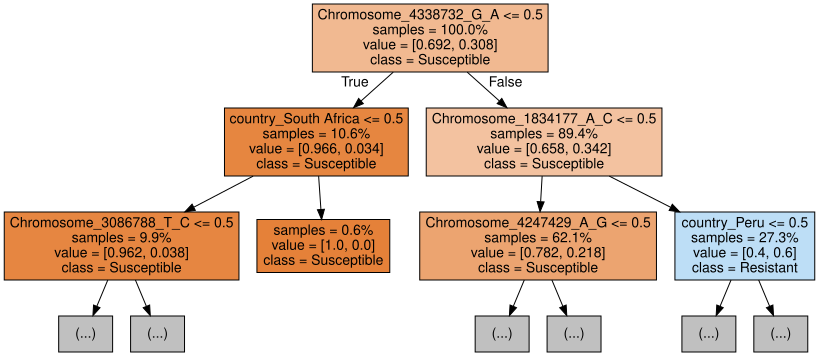

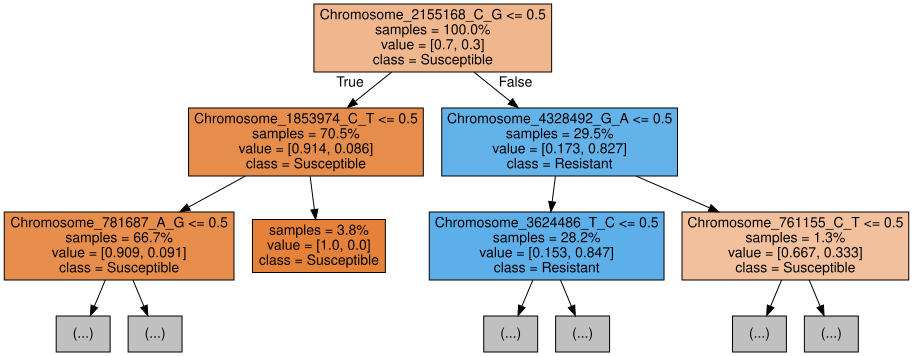

In [220]:
# === Visualize 3 Trees from Random Forest (With Lineage)
print("=== Decision Trees from Random Forest (With Lineage) ===")
for i in range(3):
    tree = rf_wi_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wi.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_with_lineage_{i}", format="png", cleanup=True)

# === Visualize 3 Trees from Random Forest (Without Lineage)
print("\n=== Decision Trees from Random Forest (Without Lineage) ===")
for i in range(3):
    tree = rf_wo_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wo.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_without_lineage_{i}", format="png", cleanup=True)


## Ethambutol Resistance

In [100]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

EMB_na = input_df['ethambutol_resistance'].isna().sum()
print("Missing values before drop:", EMB_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['ethambutol_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 101


In [102]:
columns_to_drop = ['isoniazid_resistance', 'rifampicin_resistance', 'streptomycin_resistance', 'pyrazinamide_resistance', 'levofloxacin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['ethambutol_resistance'] = input_df['ethambutol_resistance'].astype(int)

In [104]:
print("Shape after drop:", input_df.shape)

Shape after drop: (279, 118)


In [106]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

lineage    1
dtype: int64


In [108]:
input_df = input_df.dropna(subset=['lineage'])
print("Shape after drop:", input_df.shape)

Shape after drop: (278, 118)


In [110]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


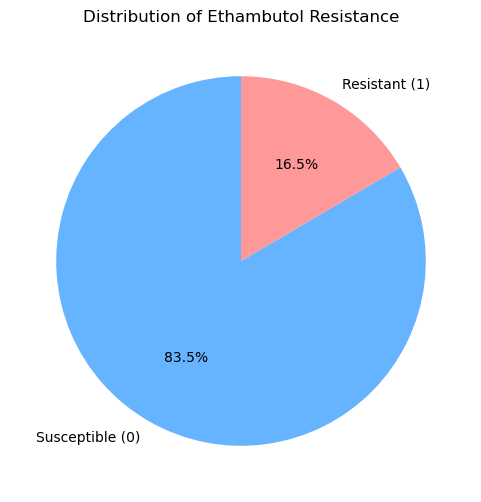

In [112]:
counts = input_df['ethambutol_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Ethambutol Resistance")
plt.show()

#### Training

In [115]:
X_with_lineage = input_df.drop(columns=['ethambutol_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['ethambutol_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (278, 117)
Shape of X_without_lineage (features): (278, 116)
Shape of y (target): (278,)


In [117]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [119]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (278, 117)
Shape of X_without_lineage: (278, 116)
Shape of y (target): (278,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (222, 116)
Testing feature shape: (56, 116)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (222, 117)
Testing feature shape: (56, 117)


In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# === WITH lineage (No SMOTE) ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results = []
cv_results.append({
    "Drug": "EMB",
    "Model": "With Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === WITHOUT lineage (No SMOTE) ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "EMB",
    "Model": "Without Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

# === Test WITH lineage (SMOTE on train) ===
pipeline_wi_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wi_test.fit(X_train_wi, y_train)
y_pred_wi_smote = pipeline_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "EMB",
    "Model": "With Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_smote),
    "Precision": precision_score(y_test, y_pred_wi_smote),
    "Recall": recall_score(y_test, y_pred_wi_smote),
    "F1 Score": f1_score(y_test, y_pred_wi_smote),
})

# === Test WITHOUT lineage (SMOTE on train) ===
pipeline_wo_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wo_test.fit(X_train_wo, y_train)
y_pred_wo_smote = pipeline_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "EMB",
    "Model": "Without Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_smote),
    "Precision": precision_score(y_test, y_pred_wo_smote),
    "Recall": recall_score(y_test, y_pred_wo_smote),
    "F1 Score": f1_score(y_test, y_pred_wo_smote),
})

#### Performance metrics

In [127]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,EMB,"With Lineage (Test, No SMOTE)",0.86,0.60,0.33,0.43
1,EMB,"Without Lineage (Test, No SMOTE)",0.84,0.50,0.22,0.31
2,EMB,"With Lineage (Test, SMOTE)",0.88,0.62,0.56,0.59
3,EMB,"Without Lineage (Test, SMOTE)",0.89,0.67,0.67,0.67


Confusion Matrix - With Lineage (Test, No SMOTE)


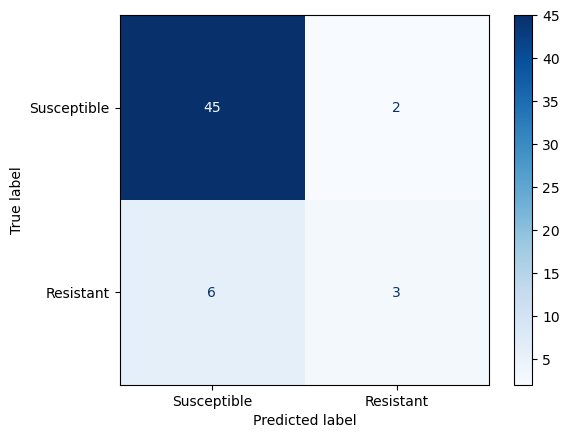

Confusion Matrix - Without Lineage (Test, No SMOTE)


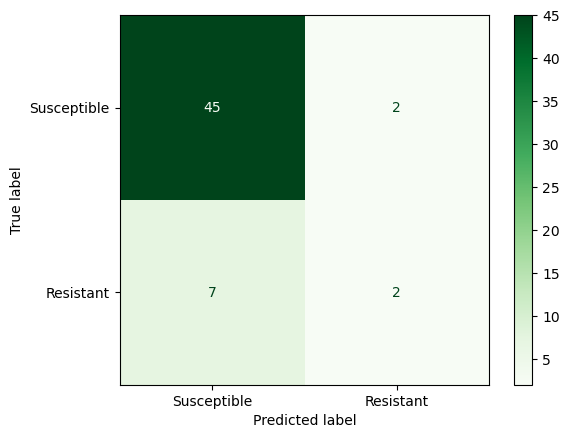

Confusion Matrix - With Lineage (Test, SMOTE)


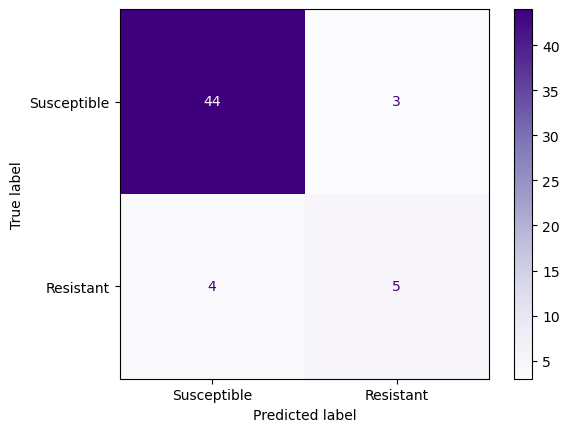

Confusion Matrix - Without Lineage (Test, SMOTE)


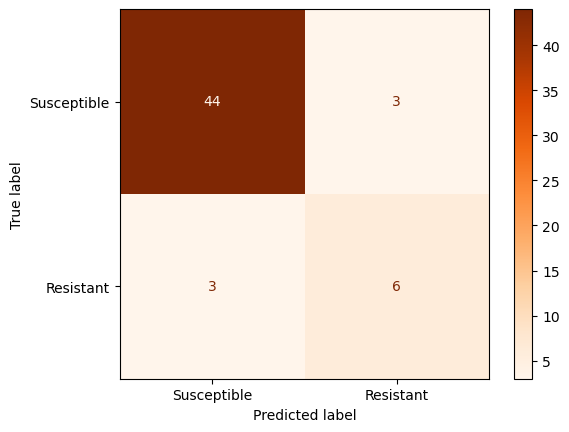

In [129]:
# === Confusion Matrix: With Lineage (Test, No SMOTE) ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, No SMOTE)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, No SMOTE) ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, No SMOTE)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

# === Confusion Matrix: With Lineage (Test, SMOTE) ===
cm_wi_smote = confusion_matrix(y_test, y_pred_wi_smote)
disp_wi_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wi_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, SMOTE)")
disp_wi_smote.plot(cmap="Purples")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, SMOTE) ===
cm_wo_smote = confusion_matrix(y_test, y_pred_wo_smote)
disp_wo_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wo_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, SMOTE)")
disp_wo_smote.plot(cmap="Oranges")
plt.grid(False)
plt.show()


## Streptomycin Resistance

In [134]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['streptomycin_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['streptomycin_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 281


majority are missing - skipping

In [137]:
columns_to_drop = ['isoniazid_resistance', 'ethambutol_resistance', 'rifampicin_resistance', 'pyrazinamide_resistance', 'levofloxacin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['streptomycin_resistance'] = input_df['streptomycin_resistance'].astype(int)

In [139]:
print("Shape after drop:", input_df.shape)

Shape after drop: (99, 113)


In [141]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


In [143]:
input_df = input_df.dropna(subset=['lineage'])
print("Shape after drop:", input_df.shape)

Shape after drop: (99, 113)


In [145]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


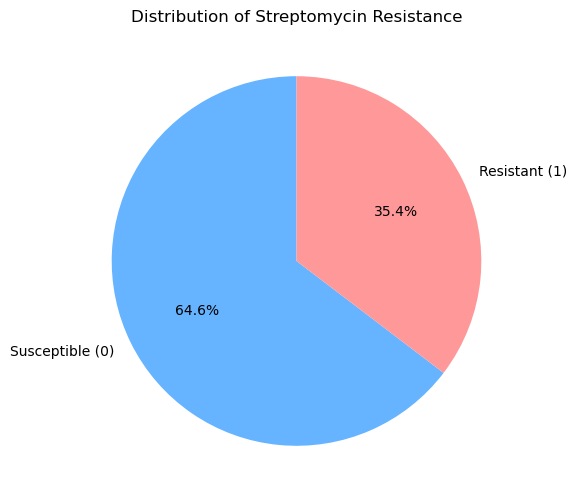

In [147]:
counts = input_df['streptomycin_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Streptomycin Resistance")
plt.show()

In [152]:
X_with_lineage = input_df.drop(columns=['streptomycin_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['streptomycin_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (99, 112)
Shape of X_without_lineage (features): (99, 111)
Shape of y (target): (99,)


In [154]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [156]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (99, 112)
Shape of X_without_lineage: (99, 111)
Shape of y (target): (99,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (79, 111)
Testing feature shape: (20, 111)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (79, 112)
Testing feature shape: (20, 112)


In [162]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# === WITH lineage (No SMOTE) ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results = []
cv_results.append({
    "Drug": "STM",
    "Model": "With Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === WITHOUT lineage (No SMOTE) ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "STM",
    "Model": "Without Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

# === Test WITH lineage (SMOTE on train) ===
pipeline_wi_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wi_test.fit(X_train_wi, y_train)
y_pred_wi_smote = pipeline_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "STM",
    "Model": "With Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_smote),
    "Precision": precision_score(y_test, y_pred_wi_smote),
    "Recall": recall_score(y_test, y_pred_wi_smote),
    "F1 Score": f1_score(y_test, y_pred_wi_smote),
})

# === Test WITHOUT lineage (SMOTE on train) ===
pipeline_wo_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wo_test.fit(X_train_wo, y_train)
y_pred_wo_smote = pipeline_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "STM",
    "Model": "Without Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_smote),
    "Precision": precision_score(y_test, y_pred_wo_smote),
    "Recall": recall_score(y_test, y_pred_wo_smote),
    "F1 Score": f1_score(y_test, y_pred_wo_smote),
})

In [164]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,STM,"With Lineage (Test, No SMOTE)",0.75,0.60,0.86,0.71
1,STM,"Without Lineage (Test, No SMOTE)",0.70,0.56,0.71,0.62
2,STM,"With Lineage (Test, SMOTE)",0.75,0.60,0.86,0.71
3,STM,"Without Lineage (Test, SMOTE)",0.70,0.55,0.86,0.67


Confusion Matrix - With Lineage (Test, No SMOTE)


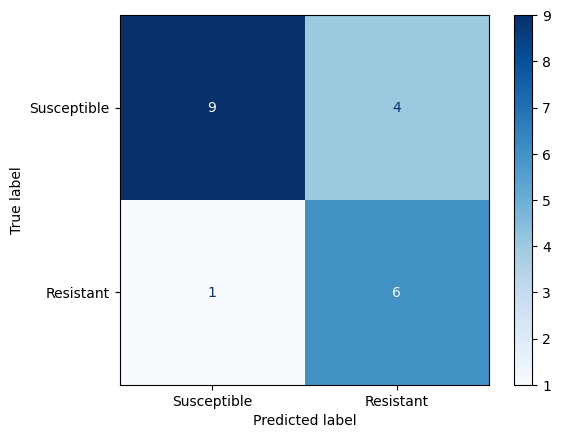

Confusion Matrix - Without Lineage (Test, No SMOTE)


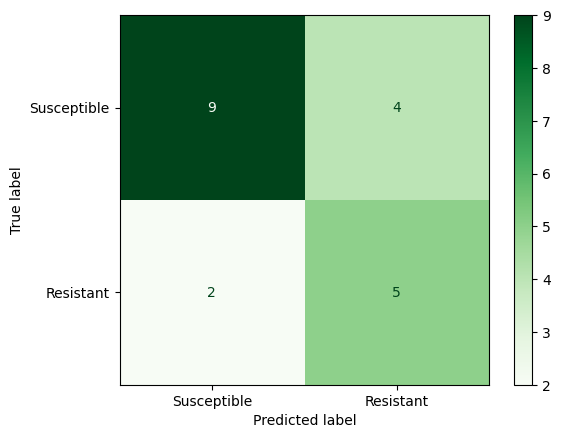

Confusion Matrix - With Lineage (Test, SMOTE)


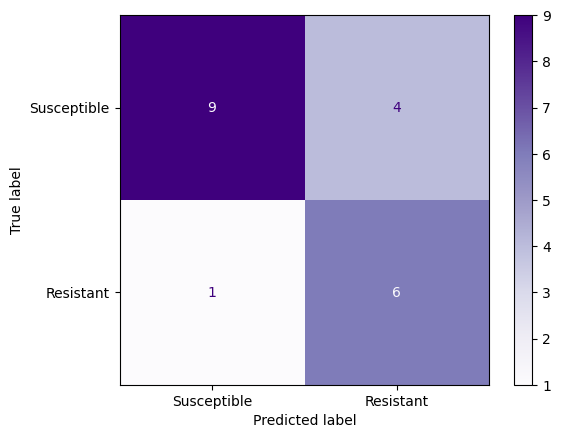

Confusion Matrix - Without Lineage (Test, SMOTE)


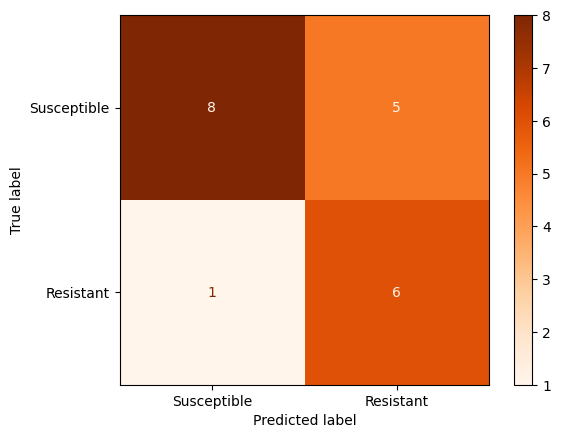

In [166]:
# === Confusion Matrix: With Lineage (Test, No SMOTE) ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, No SMOTE)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, No SMOTE) ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, No SMOTE)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

# === Confusion Matrix: With Lineage (Test, SMOTE) ===
cm_wi_smote = confusion_matrix(y_test, y_pred_wi_smote)
disp_wi_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wi_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, SMOTE)")
disp_wi_smote.plot(cmap="Purples")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, SMOTE) ===
cm_wo_smote = confusion_matrix(y_test, y_pred_wo_smote)
disp_wo_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wo_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, SMOTE)")
disp_wo_smote.plot(cmap="Oranges")
plt.grid(False)
plt.show()


## Pyrazinamide Resistance

In [176]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['pyrazinamide_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['pyrazinamide_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 273


In [178]:
columns_to_drop = ['isoniazid_resistance', 'ethambutol_resistance', 'streptomycin_resistance', 'rifampicin_resistance', 'levofloxacin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['pyrazinamide_resistance'] = input_df['pyrazinamide_resistance'].astype(int)

In [180]:
print("Shape after drop:", input_df.shape)

Shape after drop: (107, 110)


In [182]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

lineage    1
dtype: int64


In [184]:
input_df = input_df.dropna(subset=['lineage'])
print("Shape after drop:", input_df.shape)

Shape after drop: (106, 110)


In [186]:
print(input_df.isnull().sum()[input_df.isnull().sum() > 0])

Series([], dtype: int64)


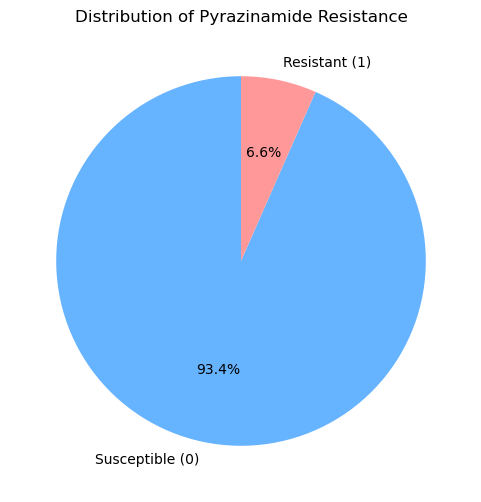

In [188]:
counts = input_df['pyrazinamide_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Pyrazinamide Resistance")
plt.show()

In [194]:
X_with_lineage = input_df.drop(columns=['pyrazinamide_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['pyrazinamide_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (106, 109)
Shape of X_without_lineage (features): (106, 108)
Shape of y (target): (106,)


In [196]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [198]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (106, 109)
Shape of X_without_lineage: (106, 108)
Shape of y (target): (106,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (84, 108)
Testing feature shape: (22, 108)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (84, 109)
Testing feature shape: (22, 109)


In [204]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# === WITH lineage (No SMOTE) ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results = []
cv_results.append({
    "Drug": "PZA",
    "Model": "With Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === WITHOUT lineage (No SMOTE) ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "PZA",
    "Model": "Without Lineage (Test, No SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

# === Test WITH lineage (SMOTE on train) ===
pipeline_wi_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wi_test.fit(X_train_wi, y_train)
y_pred_wi_smote = pipeline_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "PZA",
    "Model": "With Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_smote),
    "Precision": precision_score(y_test, y_pred_wi_smote),
    "Recall": recall_score(y_test, y_pred_wi_smote),
    "F1 Score": f1_score(y_test, y_pred_wi_smote),
})

# === Test WITHOUT lineage (SMOTE on train) ===
pipeline_wo_test = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_wo_test.fit(X_train_wo, y_train)
y_pred_wo_smote = pipeline_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "PZA",
    "Model": "Without Lineage (Test, SMOTE)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_smote),
    "Precision": precision_score(y_test, y_pred_wo_smote),
    "Recall": recall_score(y_test, y_pred_wo_smote),
    "F1 Score": f1_score(y_test, y_pred_wo_smote),
})

C:\Users\hialo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hialo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hialo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [206]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,PZA,"With Lineage (Test, No SMOTE)",0.95,0.0,0.0,0.0
1,PZA,"Without Lineage (Test, No SMOTE)",0.95,0.0,0.0,0.0
2,PZA,"With Lineage (Test, SMOTE)",0.95,0.0,0.0,0.0
3,PZA,"Without Lineage (Test, SMOTE)",1.00,1.0,1.0,1.0


Confusion Matrix - With Lineage (Test, No SMOTE)


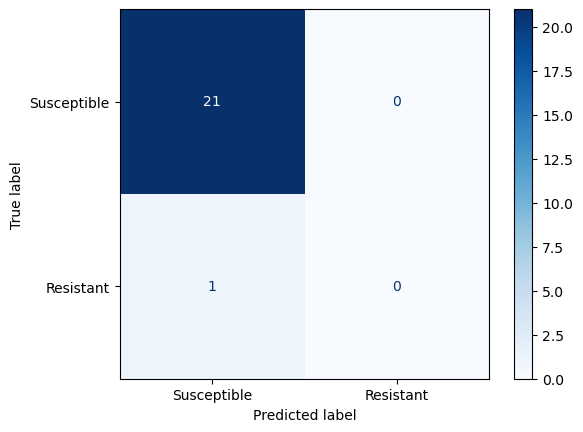

Confusion Matrix - Without Lineage (Test, No SMOTE)


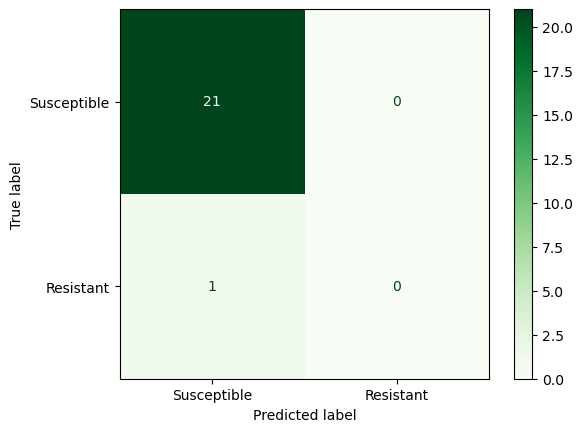

Confusion Matrix - With Lineage (Test, SMOTE)


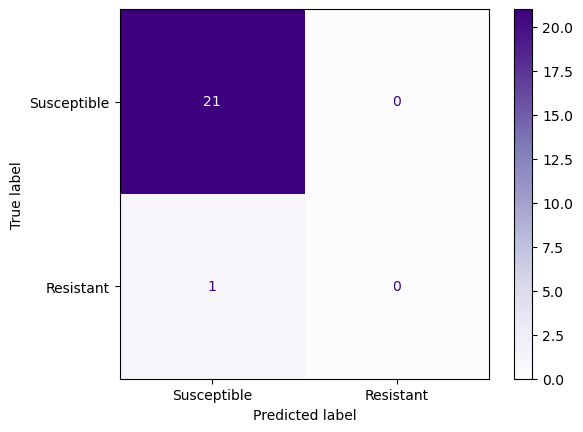

Confusion Matrix - Without Lineage (Test, SMOTE)


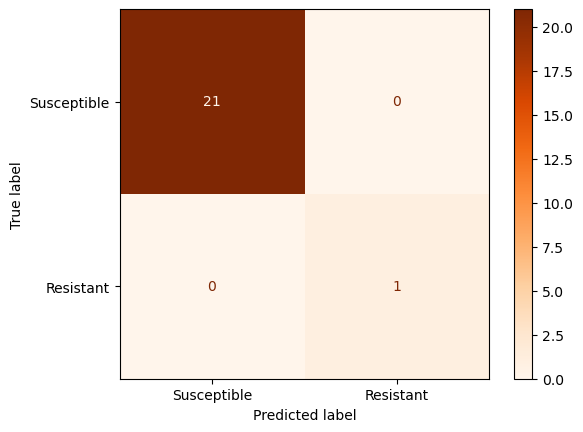

In [208]:
# === Confusion Matrix: With Lineage (Test, No SMOTE) ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, No SMOTE)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, No SMOTE) ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo,
                                 display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, No SMOTE)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

# === Confusion Matrix: With Lineage (Test, SMOTE) ===
cm_wi_smote = confusion_matrix(y_test, y_pred_wi_smote)
disp_wi_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wi_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test, SMOTE)")
disp_wi_smote.plot(cmap="Purples")
plt.grid(False)
plt.show()

# === Confusion Matrix: Without Lineage (Test, SMOTE) ===
cm_wo_smote = confusion_matrix(y_test, y_pred_wo_smote)
disp_wo_smote = ConfusionMatrixDisplay(confusion_matrix=cm_wo_smote,
                                       display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test, SMOTE)")
disp_wo_smote.plot(cmap="Oranges")
plt.grid(False)
plt.show()


## LEVOFLOXACIN RESISTANCE

In [181]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['levofloxacin_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['levofloxacin_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 187


In [183]:
columns_to_drop = ['rifampicin_resistance', 'isoniazid_resistance', "streptomycin_resistance", "pyrazinamide_resistance"]
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['levofloxacin_resistance'] = input_df['levofloxacin_resistance'].astype(int)

In [185]:
print("Shape after drop:", input_df.shape)

Shape after drop: (193, 117)


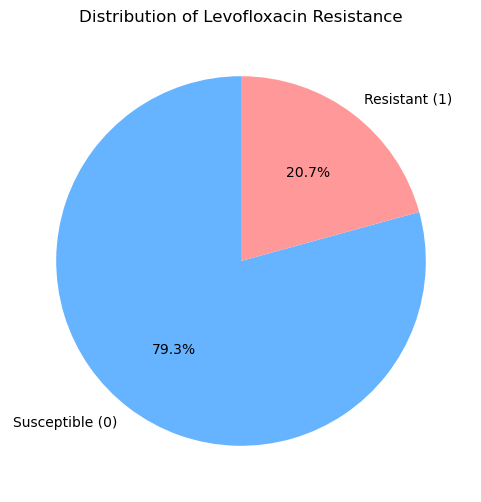

In [189]:
counts = input_df['levofloxacin_resistance'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(counts, labels=["Susceptible (0)", "Resistant (1)"],
        autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Levofloxacin Resistance")
plt.show()

END